## Module 14: Logistic Regression

### 14.4 Characteristics of sigmoid Function

In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 


In [4]:
def sigmoid(z): 
    return 1 / (1 + np.exp(-z))

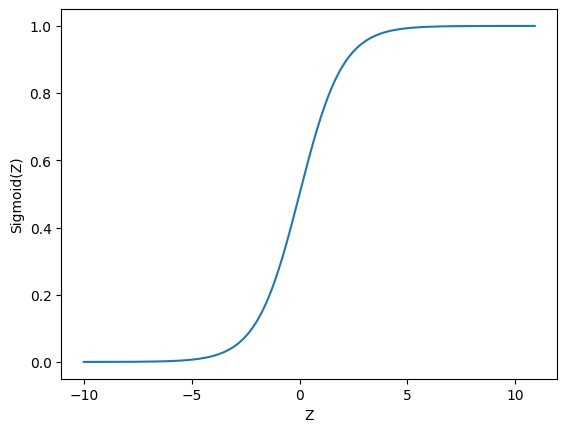

In [7]:
z = np.arange(-10, 11, 0.1) 

values = sigmoid(z) 

plt.xlabel('Z') 
plt.ylabel("Sigmoid(Z)")
plt.plot(z,values) 

plt.show()

### 14.8 Logistic Regresion from Scratch

In [35]:
X = np.array([
    [10 , 3 ],
    [20 , 5 ],
    [35, 20],
    [50, 10],
])


y = np.array([0, 0, 1, 1])

In [36]:
def sigmoid(z): 
    return 1/ (1+np.exp(-z))

In [37]:
w_init = np.array([0.5,3]) 
b_init = 0.01

In [38]:
def make_prediction(X,y,W,b): 
    m= X.shape[0]

    prob_list = np.zeros((m,)) 

    for i in range(m): 

        z = np.dot(W,X[i] + b)
        prob_list[i] = sigmoid(z)

    return prob_list  
print(make_prediction(X,y,w_init,b_init))

[0.9999992 1.        1.        1.       ]


In [44]:
w_init = np.array([0.5,-2]) 
b_init = 0.01

In [45]:
def make_prediction(X,y,W,b): 
    m= X.shape[0]

    prob_list = np.zeros((m,)) 

    for i in range(m): 

        z = np.dot(W,X[i] + b)
        prob_list[i] = sigmoid(z)

    return prob_list  
print(make_prediction(X,y,w_init,b_init))

[2.66002483e-01 4.96250070e-01 1.66670884e-10 9.93206687e-01]


In [47]:
def make_prediction(X,y,W,b,threshold=0.5): 
    m= X.shape[0]

    prob_list = np.zeros((m,)) 


    for i in range(m): 

        z = np.dot(W,X[i] + b)
        prob_list[i] = sigmoid(z) 

        prediction = (prob_list > threshold) 

    return prediction  
print(make_prediction(X,y,w_init,b_init))

[False False False  True]


In [62]:
def make_prediction(X,W,b,threshold=0.5): 
    m= X.shape[0]

    prob_list = np.zeros((m,)) 


    for i in range(m): 

        z = np.dot(W,X[i] + b)
        prob_list[i] = sigmoid(z) 


        # interpret using threshold 
        
        prediction = (prob_list > threshold) 

    return prediction  
print(make_prediction(X,w_init,b_init))

[False False False  True]


In [49]:
def compute_cost(X,y,W,b): 
    m = X.shape[0] 
    cost = 0.0 


    for i in range(m): 
        z = np.dot(W,X[i]) + b 
        prob = sigmoid(z) 

        cost = cost + ((y[i] * np.log(prob)) + ((1-y[i]) * np.log(1-prob)))
        

    cost = cost / (-m)

    return cost

compute_cost(X,y,w_init,b_init)

np.float64(5.877692344856914)

In [63]:
def calculate_gradient(X,y,W,b): 
    m = X.shape[0]
    n = X.shape[1]

    dj_dw = np.zeros((n,))
    dj_db = 0.0 

    for i in range(m): 
        z = np.dot(W,X[i]) + b 
        prob = sigmoid(z)
        error = prob - y[i] 
        dj_db = dj_db + error

        for j in range(n): 
            dj_dw[j] = dj_dw[j] +(error * X[i,j])
            
    return dj_dw / m, dj_db / m  


calculate_gradient(X,y,w_init,b_init)
            

(array([-5.66130708, -4.19002606]), np.float64(-0.059437857346274964))

In [64]:
def gradient_descent(X,y,w_input,b_input,max_iter,alpha=0.01): 
    
    w = w_input 
    b = b_input 
    cost_memo = []
    iteration = []
    for i in range(max_iter): 
        dj_dw,dj_db = calculate_gradient(X,y,w,b) 

        #update
        w = w - alpha * dj_dw
        b = b - alpha * dj_db 

        cost = compute_cost(X,y,w,b)

        cost_memo.append(cost) 
        iteration.append(i)

        if i%100 == 0: 
            print(f"Iteration:{i}: cost:{cost:0.4f}, dj_dw:{dj_dw}, dj_db:{dj_db:} w:{w}, b:{b:0.4f}") 

    return w,b,cost_memo, iteration

In [65]:
n = X.shape[1]

W_init = np.zeros((n,))
b_init = 0.0 
w_final,b_final,cost_memo,iter = gradient_descent(X,y,w_input=W_init, b_input=b_init, max_iter=100000,alpha=0.01)

Iteration:0: cost:0.7342, dj_dw:[-6.875 -2.75 ], dj_db:0.0 w:[0.06875 0.0275 ], b:0.0000
Iteration:100: cost:0.5275, dj_dw:[-0.16814113 -0.06459214], dj_db:0.18573386116115462 w:[-0.00223928  0.12907751], b:-0.1955
Iteration:200: cost:0.4928, dj_dw:[-0.00365135 -0.00602293], dj_db:0.18142544930789123 w:[-0.00048089  0.13879366], b:-0.3815
Iteration:300: cost:0.4614, dj_dw:[-0.00358581 -0.00496774], dj_db:0.1726045774071659 w:[0.00312184 0.14409632], b:-0.5584
Iteration:400: cost:0.4330, dj_dw:[-0.00343653 -0.00474241], dj_db:0.16423993595736097 w:[0.00663487 0.14893809], b:-0.7267
Iteration:500: cost:0.4073, dj_dw:[-0.00327952 -0.00457639], dj_db:0.15636156963940584 w:[0.0099917  0.15359552], b:-0.8870
Iteration:600: cost:0.3840, dj_dw:[-0.00312942 -0.00441781], dj_db:0.14896790447702332 w:[0.01319476 0.15809147], b:-1.0395
Iteration:700: cost:0.3629, dj_dw:[-0.00298761 -0.00426343], dj_db:0.1420467830465195 w:[0.01625186 0.16243096], b:-1.1850
Iteration:800: cost:0.3436, dj_dw:[-0.002

In [66]:
print(w_final) 
print(b_final)

[0.22918287 0.49060656]
-11.172459126367535


In [68]:
prediction = make_prediction(X,w_final,b_final).astype(int) 
print(prediction)

[0 0 1 1]
